# 02. Результаты: сводка экспериментов

Все числа — онлайн-симуляция замороженных `run.py`+`score.py` на 56 сессиях train. Сводная таблица — `results/summary.md`, хронология — `research/WORKLOG.md`.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'assets' else Path.cwd()
sys.path.insert(0, str(ROOT / 'tools')); sys.path.insert(0, str(ROOT / 'solution'))
import numpy as np, pandas as pd
from IPython.display import Image, Markdown, display
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
EXP = ROOT / 'results' / 'experiments'; FIG = ROOT / 'results' / 'figures'

In [2]:
m = json.load(open(ROOT / 'results/metrics/metrics.json'))
l = json.load(open(EXP / 'E12_final_loso/final/metrics.json'))
mvp = json.load(open(EXP / 'E00_mvp/metrics.json'))
pd.DataFrame([{'прогон': n, 'F': x['hybrid']['min_f1'], 'P': x['hybrid']['macro_recall'], 'NIRS F': x['nirs_only']['min_f1'], 'EEG F': x['eeg_only_info']['min_f1'], 'штраф': x['timings']['penalty_total'], 'балл': x['score']['total']} for n, x in [('MVP (утечка Δt)', mvp), ('финал, LOSO', l), ('финал, in-sample (results/metrics)', m)]]).round(4)

,прогон,F,P,NIRS F,EEG F,штраф,балл
0,MVP (утечка Δt),0.4718,0.6176,0.3828,0.4576,0,57.5793
1,"финал, LOSO",0.5067,0.6400,0.4032,0.4730,0,60.6508
2,"финал, in-sample (results/metrics)",0.5391,0.6635,0.4032,0.5170,0,63.3017


In [3]:
S = pd.read_csv(ROOT / 'results/summary_all.csv')
S.sort_values('балл', ascending=False).head(25)

,эксперимент,конфигурация,F,P,NIRS F,EEG F,балл,ДИ балла,AUC покой/вообр. (ЭЭГ),AUC Л/П (ЭЭГ),оценка,"fit max, с","predict max, с"
129,E11_controls,final_ch_all17,0.5331,0.6581,0.4032,0.4980,62.7817,[56.7; 68.6],0.8870,0.6984,LOSO,6.7145,0.1097
131,E12_final_loso,final,0.5067,0.6400,0.4032,0.4730,60.6508,[54.4; 66.8],0.8767,0.6745,LOSO,1.2041,0.0301
116,E10_fusion,G_biasS,0.5067,0.6400,0.4032,0.4730,60.6508,[54.4; 66.8],0.8767,0.6745,LOSO,3.1875,0.1239
126,E11_controls,final,0.5067,0.6400,0.4032,0.4730,60.6508,[54.4; 66.8],0.8767,0.6745,LOSO,2.5683,0.0606
106,E10_fusion,D_norm_T1_k1,0.5039,0.6414,0.3986,0.4709,60.4543,[54.3; 66.4],0.8767,0.6745,LOSO,1.3912,0.0516
117,E10_fusion,G_globC0.01,0.5038,0.6414,0.3986,0.4705,60.4467,[54.3; 66.4],0.8769,0.6744,LOSO,1.3375,0.0764
118,E10_fusion,G_globC1,0.5037,0.6413,0.3986,0.4710,60.4429,[54.3; 66.4],0.8767,0.6745,LOSO,1.1020,0.0757
105,E10_fusion,D_norm_T1_k0.5,0.5037,0.6404,0.3986,0.4693,60.4126,[54.2; 66.5],0.8781,0.6694,LOSO,1.2363,0.1071
113,E10_fusion,E_loglinear_session,0.5031,0.6358,0.4050,0.4730,60.3323,[54.0; 66.3],0.8767,0.6745,LOSO,2.8246,0.1065
128,E11_controls,final_band40,0.4996,0.6399,0.4032,0.4675,60.2203,[54.0; 66.2],0.8762,0.6688,LOSO,3.7055,0.0507


In [4]:
print(json.dumps(json.load(open(EXP / 'E12_final_loso/nested.json'))['nested'], indent=1))
cmp = EXP / 'E12_final_loso/compare_mvp.json'
if cmp.exists(): print(cmp.read_text())

{
 "F": 0.5067027404073297,
 "P": 0.6400057739313415,
 "NF": 0.40323282999500615,
 "score": 60.650830092305114
}
{
 "MVP (с утечкой Δt):hyb_min_f1": {
  "key": "hyb_min_f1",
  "mean_diff_sessions": 0.03489642857142856,
  "mean_diff_subjects": 0.03602238095238094,
  "n_subjects_better": 11,
  "n_subjects": 14,
  "wilcoxon_p": 0.029541015625,
  "ci95_diff": [
   0.0011739504870129814,
   0.07278825892857135
  ]
 },
 "MVP (с утечкой Δt):hyb_recall": {
  "key": "hyb_recall",
  "mean_diff_sessions": 0.022400000000000003,
  "mean_diff_subjects": 0.023152142857142868,
  "n_subjects_better": 8,
  "n_subjects": 14,
  "wilcoxon_p": 0.067626953125,
  "ci95_diff": [
   0.0003431489028213154,
   0.04826025974025974
  ]
 },
 "MVP (с утечкой Δt):nirs_min_f1": {
  "key": "nirs_min_f1",
  "mean_diff_sessions": 0.020394444444444444,
  "mean_diff_subjects": 0.02014059523809524,
  "n_subjects_better": 11,
  "n_subjects": 14,
  "wilcoxon_p": 0.029541015625,
  "ci95_diff": [
   -0.00021493653516295883,
   0

In [5]:
d = pd.read_csv(EXP / 'E12_final_loso/final/per_session_extra.csv')
d[['session', 'hyb_min_f1', 'hyb_recall', 'eeg_min_f1', 'nirs_min_f1', 'eeg_auc_rest_im', 'eeg_auc_lr']].round(3)

,session,hyb_min_f1,hyb_recall,eeg_min_f1,nirs_min_f1,eeg_auc_rest_im,eeg_auc_lr
0,2025.12.01.16.04.01_N01,0.410,0.504,0.392,0.341,0.725,0.636
1,2025.12.04.13.29.33_N01,0.758,0.826,0.728,0.471,0.912,0.960
2,2025.12.08.14.19.05_N02,0.397,0.566,0.312,0.438,0.885,0.657
3,2025.12.09.12.52.43_N01,0.785,0.858,0.762,0.491,0.955,0.961
4,2025.12.11.12.13.46_N03,0.623,0.713,0.647,0.347,0.939,0.854
5,2025.12.11.15.27.59_N02,0.554,0.655,0.490,0.391,0.902,0.640
6,2025.12.11.15.43.58_N02,0.451,0.588,0.365,0.446,0.899,0.490
7,2025.12.15.12.52.57_N03,0.472,0.658,0.468,0.300,0.944,0.740
8,2025.12.15.13.16.37_N03,0.595,0.723,0.613,0.394,0.936,0.840
9,2025.12.18.12.09.22_N03,0.579,0.727,0.579,NaN,0.990,0.735


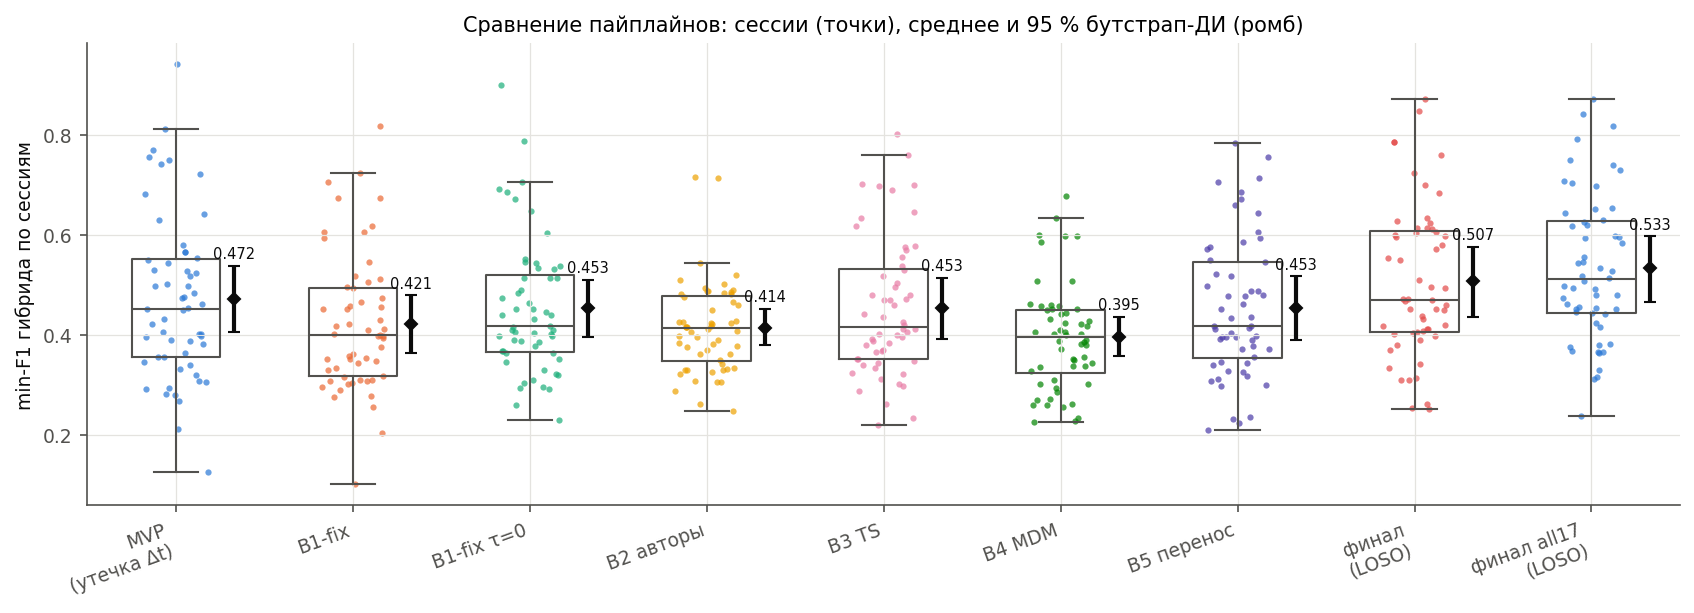

In [6]:
display(Image(filename=str(FIG / 'pipelines_comparison.png')))

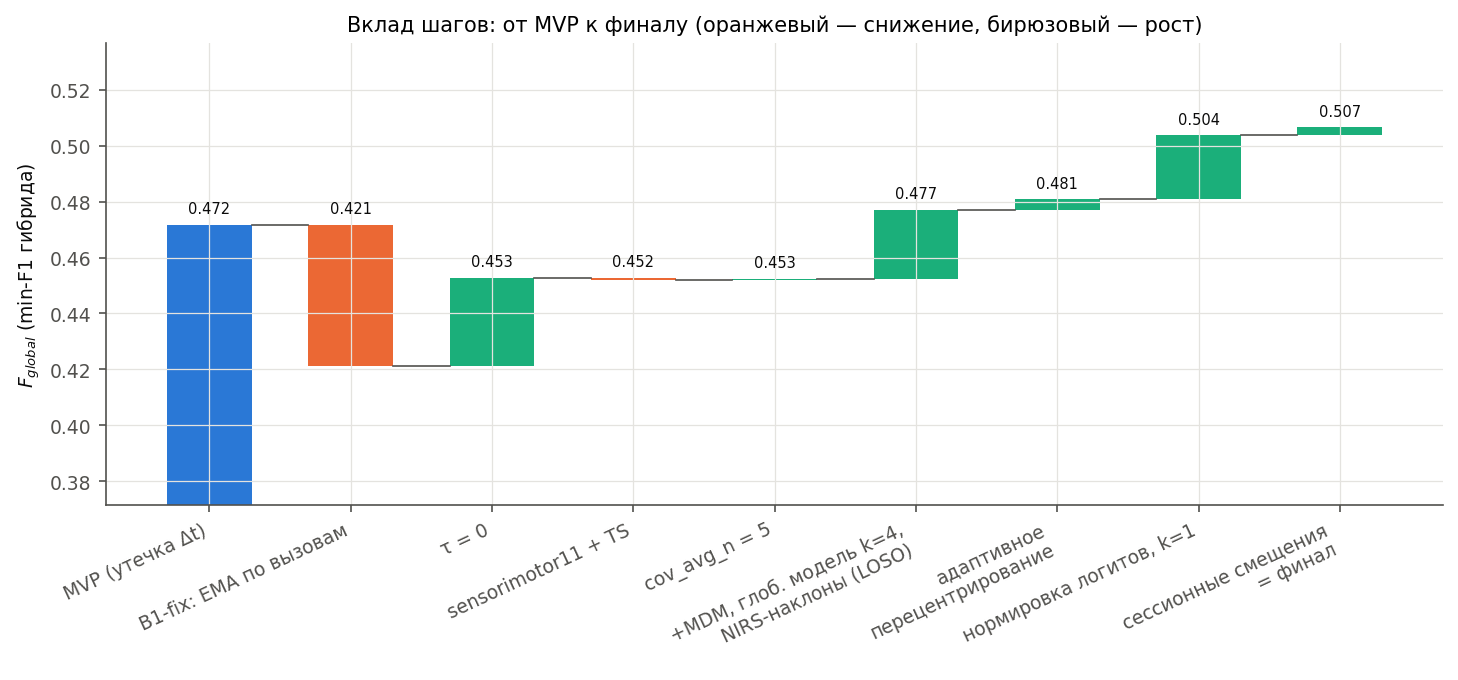

In [7]:
display(Image(filename=str(FIG / 'ablation_waterfall.png')))

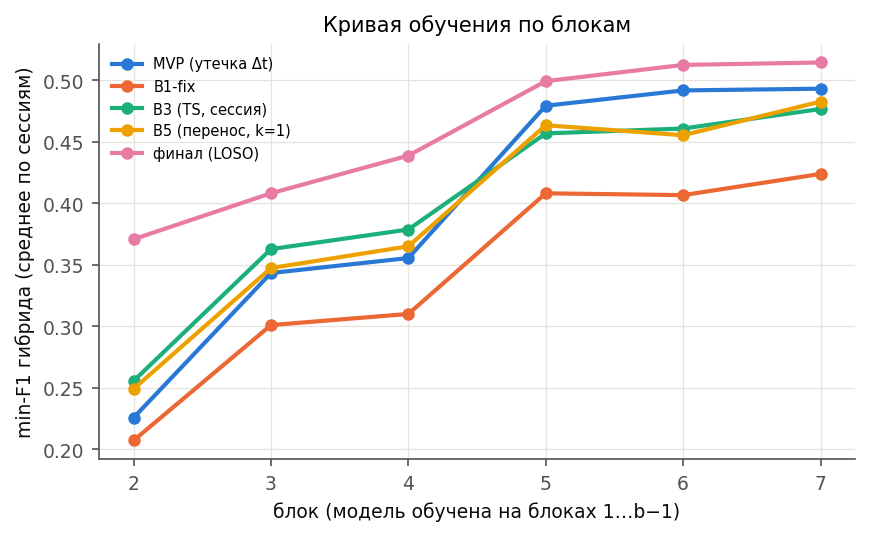

In [8]:
display(Image(filename=str(FIG / 'learning_curve_blocks.png')))

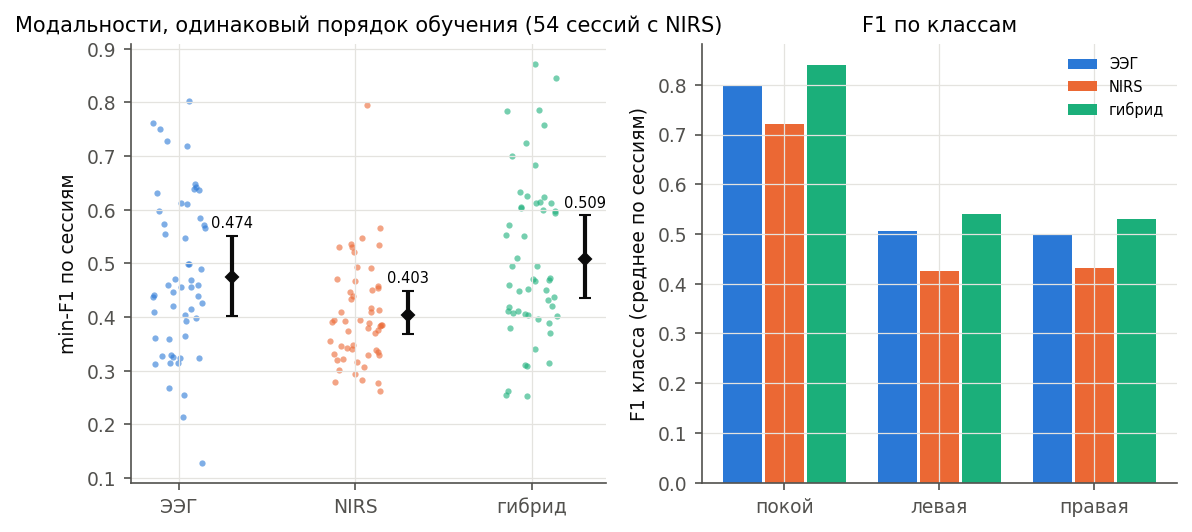

In [9]:
display(Image(filename=str(FIG / 'modalities.png')))

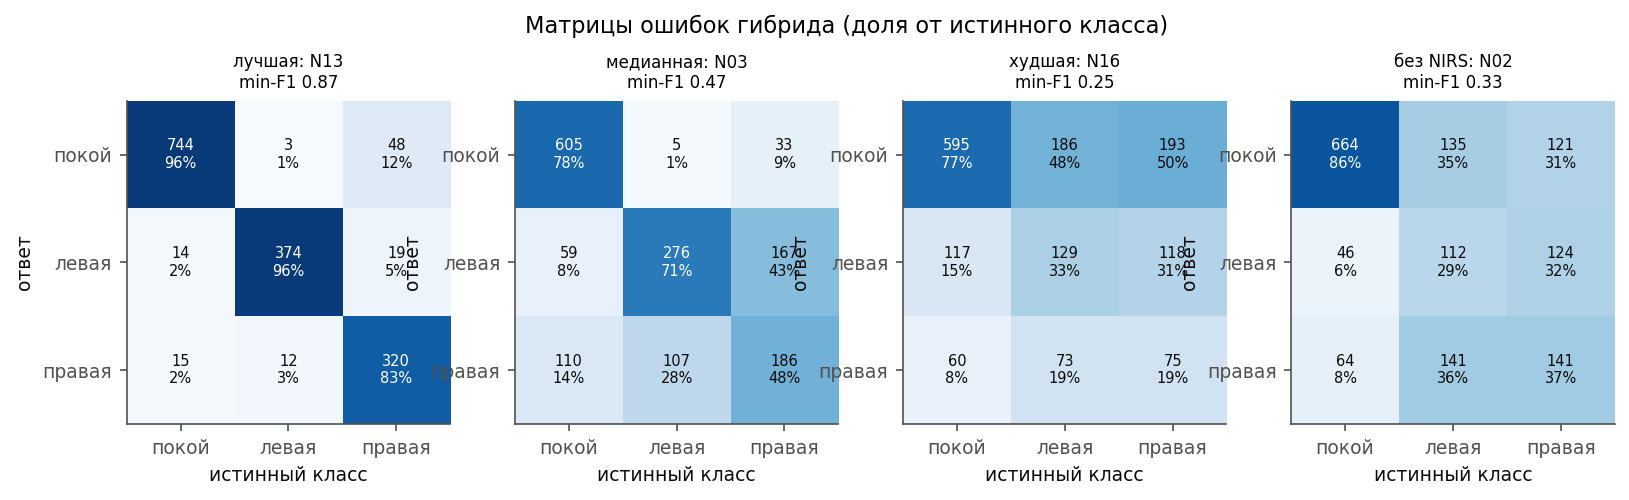

In [10]:
display(Image(filename=str(FIG / 'confusion_examples.png')))